# 5. Eksploracyjna analiza danych (EDA)

W ramach eksploracyjnej analizy danych przeprowadzono wstępne rozpoznanie struktury oraz charakterystyki analizowanego zbioru danych. Celem tego etapu było zrozumienie właściwości danych, identyfikacja potencjalnych problemów jakościowych oraz wskazanie zależności istotnych z perspektywy dalszego modelowania predykcyjnego.

W ramach analizy wykonano między innymi:

- analizę struktury zbioru danych oraz typów zmiennych,
- identyfikację brakujących wartości,
- analizę statystyk opisowych wybranych zmiennych,
- analizę rozkładu zmiennej docelowej `listPrice`,
- analizę zależności pomiędzy powierzchnią nieruchomości (`sqft`) a ceną ofertową,
- identyfikację wartości odstających,
- analizę korelacji pomiędzy wybranymi zmiennymi numerycznymi,
- wstępną analizę danych tekstowych zawartych w opisach ofert nieruchomości,
- podstawowe przygotowanie danych tekstowych do dalszej analizy NLP,
- analizę najczęściej występujących słów oraz porównanie opisów tańszych i droższych nieruchomości.

Uzyskane wyniki stanowią podstawę do dalszego etapu przygotowania danych oraz budowy modeli uczenia maszynowego.

In [1]:
# ============================================================
# Import bibliotek
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ============================================================
# ustawienia wyświetlania
# ============================================================

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
# ============================================================
# Wczytanie zbioru danych
# ============================================================

df = pd.read_csv("../data/raw/new_york_real_estate_2026_final.csv")
print("Rozmiar zbioru danych:", df.shape)
df.head()

Rozmiar zbioru danych: (8273, 11)


,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage
0,single_family,NaN,No description provided.,325000.0,1252.0,2.0,3.0,2.0,2.0,2.0,1.0
1,single_family,NaN,Shortsale.,308000.0,NaN,NaN,4.0,4.0,4.0,4.0,NaN
2,multi_family,NaN,Discover an exceptional investment opportunity...,799999.0,NaN,NaN,11.0,6.0,7.0,7.0,1.0
3,single_family,NaN,Classic Cape Cod with 4 bedrooms and 2 full ba...,189900.0,1400.0,3.0,4.0,2.0,2.0,2.0,2.0
4,single_family,NaN,"Spacious 4-bedroom, 2.5-bath two-story home of...",204900.0,2074.0,2.0,4.0,2.0,2.0,2.0,2.0


In [4]:
# ============================================================
# Struktura zbioru danych
# ============================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8273 entries, 0 to 8272
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   type             8273 non-null   object 
 1   sub_type         1898 non-null   object 
 2   text             8273 non-null   object 
 3   listPrice        8273 non-null   float64
 4   sqft             7167 non-null   float64
 5   stories          4097 non-null   float64
 6   beds             7933 non-null   float64
 7   baths            7882 non-null   float64
 8   baths_full       7846 non-null   float64
 9   baths_full_calc  7855 non-null   float64
 10  garage           4062 non-null   float64
dtypes: float64(8), object(3)
memory usage: 711.1+ KB


In [5]:
# ============================================================
# Statystyki opisowe
# ============================================================

df.describe()

,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage
count,8.273000e+03,7.167000e+03,4097.000000,7933.000000,7882.000000,7846.000000,7855.000000,4062.000000
mean,1.094366e+06,2.330063e+03,3.247742,3.439178,2.481604,2.104384,2.117632,2.870261
std,2.542967e+06,1.773651e+04,6.315546,2.058459,1.602000,1.350849,1.353833,30.457501
min,1.000000e+00,1.000000e+00,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,2.500000e+05,1.210000e+03,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000
50%,5.299000e+05,1.680000e+03,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000
75%,9.490000e+05,2.400000e+03,2.000000,4.000000,3.000000,2.000000,2.000000,2.000000
max,8.000000e+07,1.481040e+06,96.000000,100.000000,40.000000,30.000000,30.000000,1440.000000


In [6]:
# ============================================================
# Podsumowanie jakości i statystyk danych
# ============================================================

summary_table = pd.DataFrame({
    "dtype": df.dtypes,
    "missing_count": df.isnull().sum(),
    "missing_percent": df.isnull().mean() * 100,
    "mean": df.mean(numeric_only=True),
    "median": df.median(numeric_only=True),
    "std": df.std(numeric_only=True),
    "min": df.min(numeric_only=True),
    "max": df.max(numeric_only=True)
})

summary_table = summary_table.sort_values(
    by="missing_percent",
    ascending=False
)

summary_table = summary_table.round(2)

summary_table

,dtype,missing_count,missing_percent,mean,median,std,min,max
sub_type,object,6375,77.06,NaN,NaN,NaN,NaN,NaN
garage,float64,4211,50.90,2.87,2.0,30.46,1.0,1440.0
stories,float64,4176,50.48,3.25,2.0,6.32,1.0,96.0
sqft,float64,1106,13.37,2330.06,1680.0,17736.51,1.0,1481040.0
baths_full,float64,427,5.16,2.10,2.0,1.35,1.0,30.0
baths_full_calc,float64,418,5.05,2.12,2.0,1.35,1.0,30.0
baths,float64,391,4.73,2.48,2.0,1.60,0.0,40.0
beds,float64,340,4.11,3.44,3.0,2.06,0.0,100.0
listPrice,float64,0,0.00,1094366.49,529900.0,2542966.54,1.0,80000000.0
text,object,0,0.00,NaN,NaN,NaN,NaN,NaN


In [7]:
# ============================================================
# Podstawowe ustawienia wykresów
# ============================================================

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

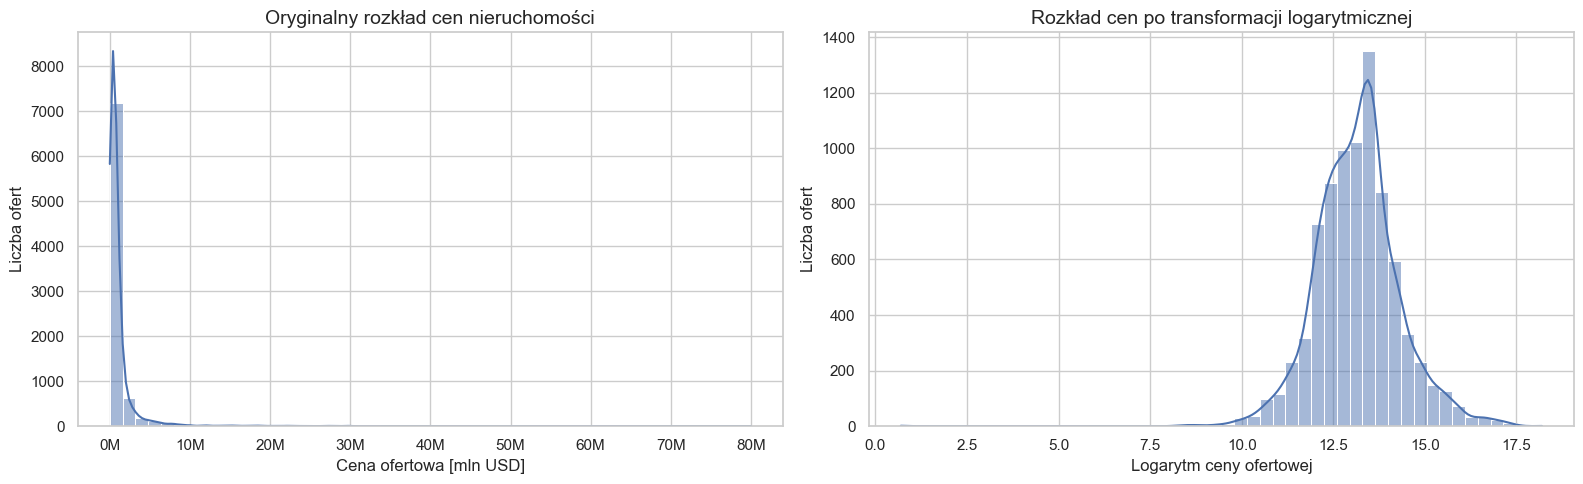

In [8]:
# ============================================================
# Rozkład zmiennej listPrice
# ============================================================

from matplotlib.ticker import FuncFormatter

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ============================================================
# Oryginalny rozkład cen nieruchomości
# ============================================================

sns.histplot(
    df["listPrice"],
    bins=50,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Oryginalny rozkład cen nieruchomości")
axes[0].set_xlabel("Cena ofertowa [mln USD]")
axes[0].set_ylabel("Liczba ofert")

# formatowanie osi X do milionów USD
axes[0].xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x / 1_000_000:.0f}M")
)

# ============================================================
# Rozkład po transformacji logarytmicznej
# ============================================================

sns.histplot(
    np.log1p(df["listPrice"]),
    bins=50,
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Rozkład cen po transformacji logarytmicznej")
axes[1].set_xlabel("Logarytm ceny ofertowej")
axes[1].set_ylabel("Liczba ofert")

plt.tight_layout()
plt.show()

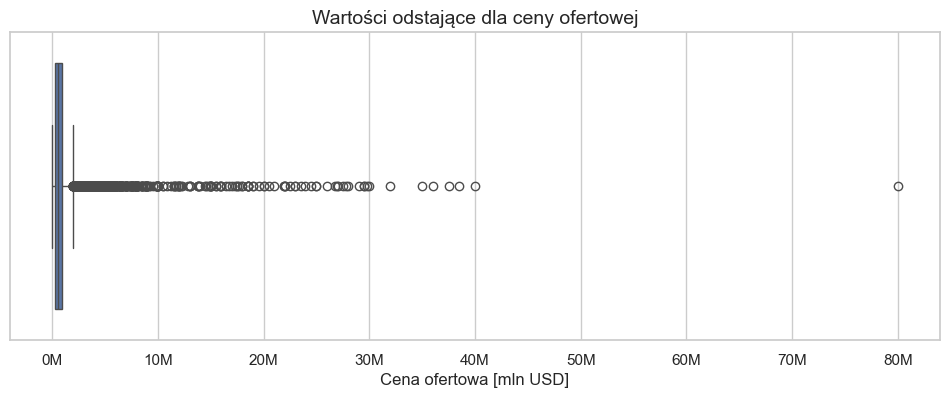

In [9]:
# ============================================================
# Analiza wartości odstających dla zmiennej listPrice
# ============================================================

from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(12, 4))

sns.boxplot(x=df["listPrice"])

plt.title("Wartości odstające dla ceny ofertowej")
plt.xlabel("Cena ofertowa [mln USD]")

# formatowanie osi X do milionów USD
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x / 1_000_000:.0f}M")
)

plt.show()

In [10]:
# ============================================================
# Porównanie średniej i mediany ceny
# ============================================================

price_summary = pd.DataFrame({
    "mean": [df["listPrice"].mean()],
    "median": [df["listPrice"].median()],
    "std": [df["listPrice"].std()],
    "min": [df["listPrice"].min()],
    "max": [df["listPrice"].max()]
}).round(2)

price_summary

,mean,median,std,min,max
0,1094366.49,529900.0,2542966.54,1.0,80000000.0


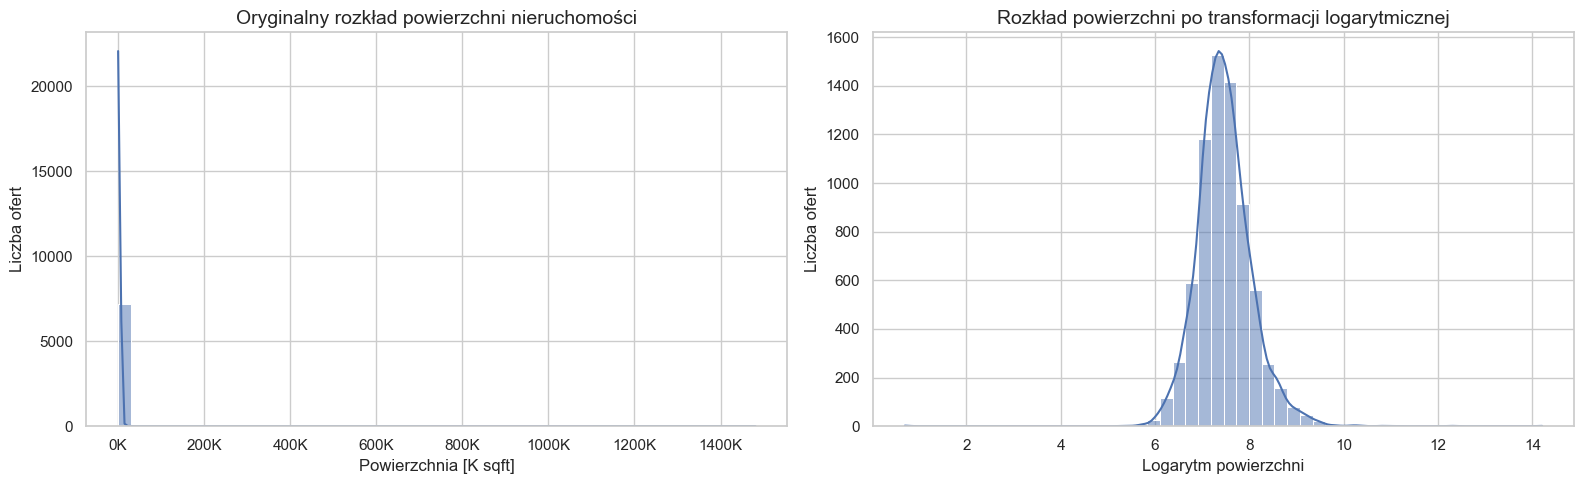

In [11]:
# ============================================================
# Analiza zmiennej sqft
# ============================================================

from matplotlib.ticker import FuncFormatter

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(
    df["sqft"],
    bins=50,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Oryginalny rozkład powierzchni nieruchomości")
axes[0].set_xlabel("Powierzchnia [K sqft]")
axes[0].set_ylabel("Liczba ofert")

axes[0].xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x / 1_000:.0f}K")
)

sns.histplot(
    np.log1p(df["sqft"].dropna()),
    bins=50,
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Rozkład powierzchni po transformacji logarytmicznej")
axes[1].set_xlabel("Logarytm powierzchni")
axes[1].set_ylabel("Liczba ofert")

plt.tight_layout()
plt.show()

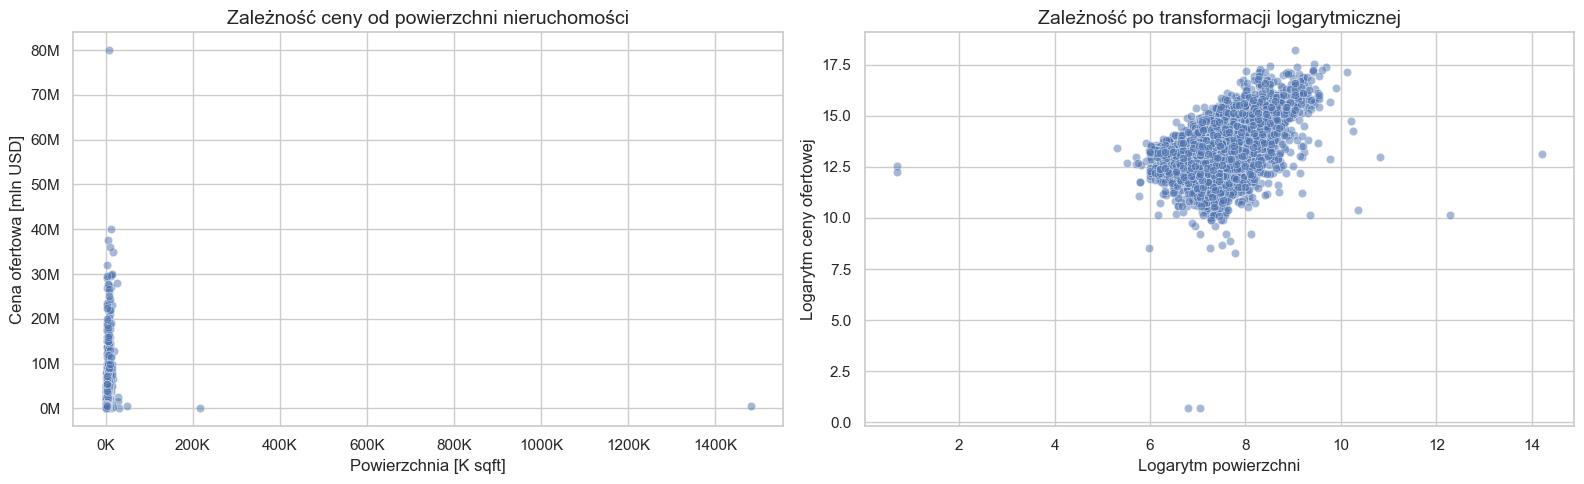

In [12]:
# ============================================================
# Zależność ceny od powierzchni nieruchomości
# ============================================================

from matplotlib.ticker import FuncFormatter

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ============================================================
# Oryginalna zależność
# ============================================================

sns.scatterplot(
    data=df,
    x="sqft",
    y="listPrice",
    alpha=0.5,
    ax=axes[0]
)

axes[0].set_title("Zależność ceny od powierzchni nieruchomości")
axes[0].set_xlabel("Powierzchnia [K sqft]")
axes[0].set_ylabel("Cena ofertowa [mln USD]")

axes[0].xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x / 1_000:.0f}K")
)

axes[0].yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f"{y / 1_000_000:.0f}M")
)

# ============================================================
# Zależność po transformacji logarytmicznej
# ============================================================

sns.scatterplot(
    x=np.log1p(df["sqft"]),
    y=np.log1p(df["listPrice"]),
    alpha=0.5,
    ax=axes[1]
)

axes[1].set_title("Zależność po transformacji logarytmicznej")
axes[1].set_xlabel("Logarytm powierzchni")
axes[1].set_ylabel("Logarytm ceny ofertowej")

plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# Korelacja pomiędzy powierzchnią a ceną
# ============================================================

sqft_price_corr = df[["sqft", "listPrice"]].corr().round(3)

sqft_price_corr

,sqft,listPrice
sqft,1.000,0.043
listPrice,0.043,1.000


In [14]:
# ============================================================
# Wstępna analiza danych tekstowych
# ============================================================

import re
from collections import Counter

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [15]:
# ============================================================
# Długość opisów ofert
# ============================================================

df["text_length"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()

text_summary = df[["text_length", "word_count"]].describe().T.round(2)

text_summary

,count,mean,std,min,25%,50%,75%,max
text_length,8273.0,1092.01,679.92,1.0,600.0,970.0,1451.0,4004.0
word_count,8273.0,168.44,103.12,1.0,95.0,150.0,222.0,685.0


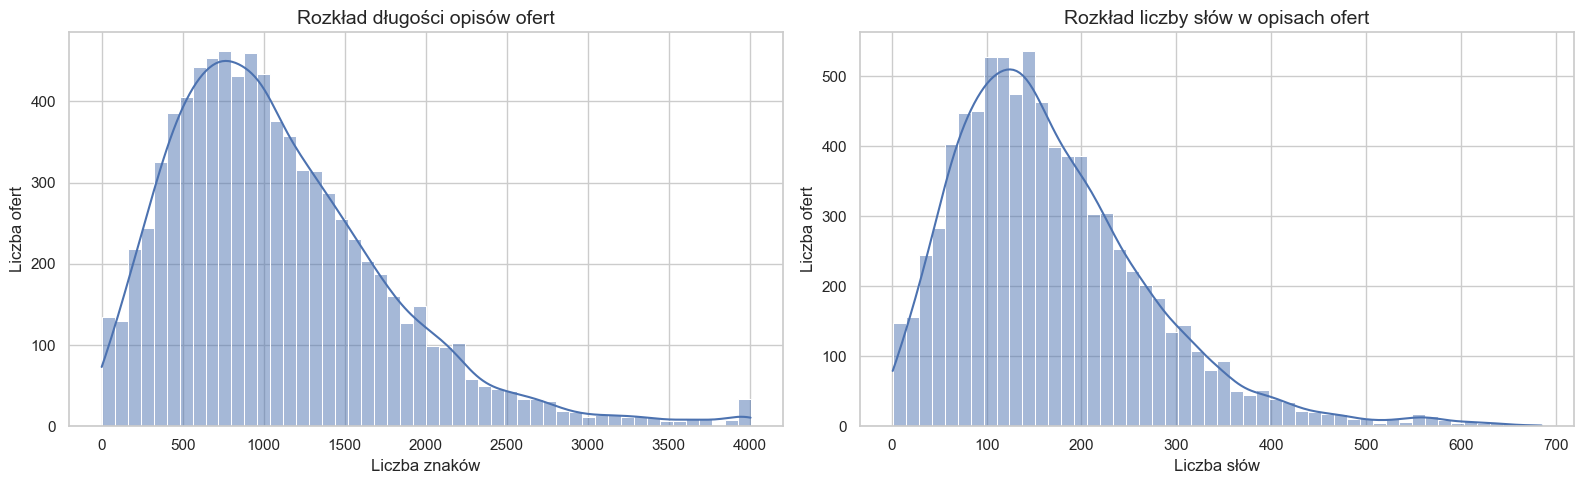

In [16]:
# ============================================================
# Rozkład długości opisów ofert
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(
    df["text_length"],
    bins=50,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Rozkład długości opisów ofert")
axes[0].set_xlabel("Liczba znaków")
axes[0].set_ylabel("Liczba ofert")

sns.histplot(
    df["word_count"],
    bins=50,
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Rozkład liczby słów w opisach ofert")
axes[1].set_xlabel("Liczba słów")
axes[1].set_ylabel("Liczba ofert")

plt.tight_layout()
plt.show()

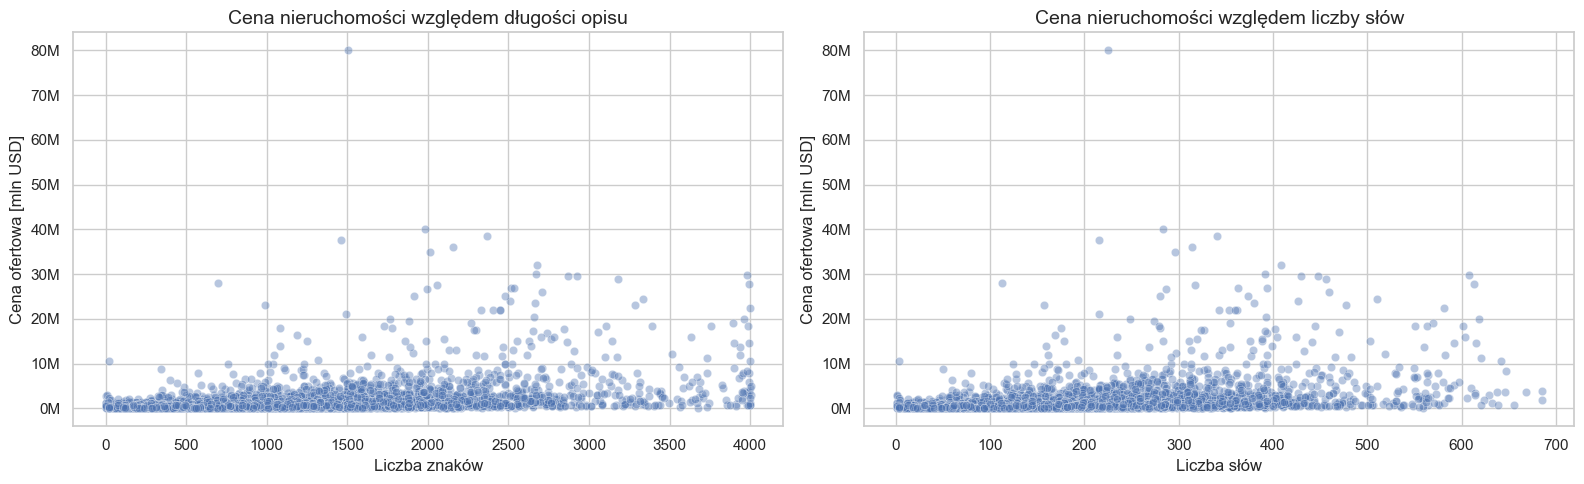

In [17]:
# ============================================================
# Zależność ceny od długości opisu oferty
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.scatterplot(
    data=df,
    x="text_length",
    y="listPrice",
    alpha=0.4,
    ax=axes[0]
)

axes[0].set_title("Cena nieruchomości względem długości opisu")
axes[0].set_xlabel("Liczba znaków")
axes[0].set_ylabel("Cena ofertowa [mln USD]")

axes[0].yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f"{y / 1_000_000:.0f}M")
)

sns.scatterplot(
    data=df,
    x="word_count",
    y="listPrice",
    alpha=0.4,
    ax=axes[1]
)

axes[1].set_title("Cena nieruchomości względem liczby słów")
axes[1].set_xlabel("Liczba słów")
axes[1].set_ylabel("Cena ofertowa [mln USD]")

axes[1].yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f"{y / 1_000_000:.0f}M")
)

plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# Podstawowe czyszczenie tekstu
# ============================================================

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


df["clean_text"] = df["text"].apply(clean_text)

df[["text", "clean_text"]].head()

,text,clean_text
0,No description provided.,no description provided
1,Shortsale.,shortsale
2,Discover an exceptional investment opportunity...,discover an exceptional investment opportunity...
3,Classic Cape Cod with 4 bedrooms and 2 full ba...,classic cape cod with bedrooms and full baths ...
4,"Spacious 4-bedroom, 2.5-bath two-story home of...",spacious bedroom bath two story home offering ...


In [19]:
# ============================================================
# Najczęściej występujące słowa w opisach ofert
# ============================================================

stop_words = set(ENGLISH_STOP_WORDS)

all_words = " ".join(df["clean_text"]).split()

filtered_words = [
    word for word in all_words
    if word not in stop_words and len(word) > 2
]

word_freq = Counter(filtered_words)

top_words = pd.DataFrame(
    word_freq.most_common(20),
    columns=["word", "count"]
)

top_words

,word,count
0,home,15058
1,room,11413
2,living,10827
3,space,8226
4,bedroom,7194
5,offers,6918
6,kitchen,6799
7,new,6217
8,floor,5718
9,bath,5583


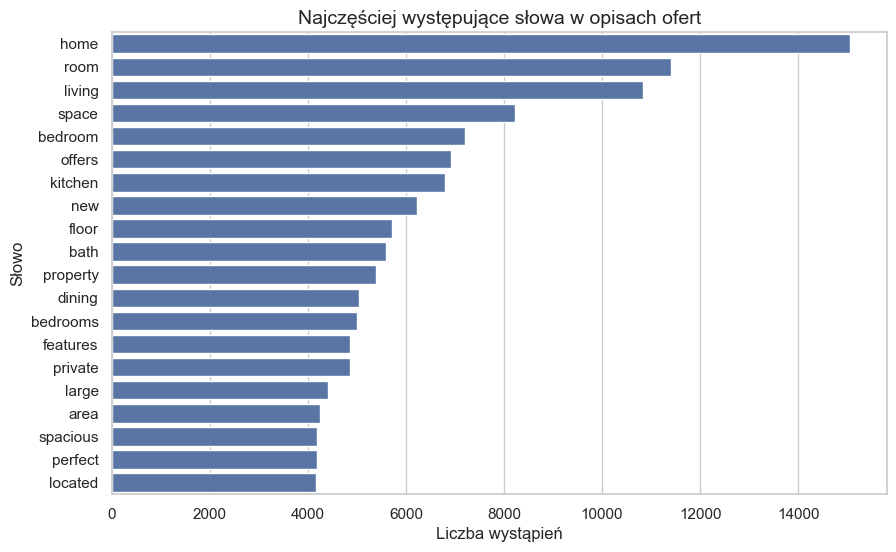

In [20]:
# ============================================================
# Wizualizacja najczęściej występujących słów
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_words,
    x="count",
    y="word"
)

plt.title("Najczęściej występujące słowa w opisach ofert")
plt.xlabel("Liczba wystąpień")
plt.ylabel("Słowo")

plt.show()

In [21]:
# ============================================================
# Porównanie słów w tanich i drogich ofertach
# ============================================================

lower_price_limit = df["listPrice"].quantile(0.25)
upper_price_limit = df["listPrice"].quantile(0.75)

low_price_text = df.loc[
    df["listPrice"] <= lower_price_limit,
    "clean_text"
]

high_price_text = df.loc[
    df["listPrice"] >= upper_price_limit,
    "clean_text"
]

low_price_words = [
    word for word in " ".join(low_price_text).split()
    if word not in stop_words and len(word) > 2
]

high_price_words = [
    word for word in " ".join(high_price_text).split()
    if word not in stop_words and len(word) > 2
]

low_price_top_words = pd.DataFrame(
    Counter(low_price_words).most_common(15),
    columns=["word", "count"]
)

high_price_top_words = pd.DataFrame(
    Counter(high_price_words).most_common(15),
    columns=["word", "count"]
)

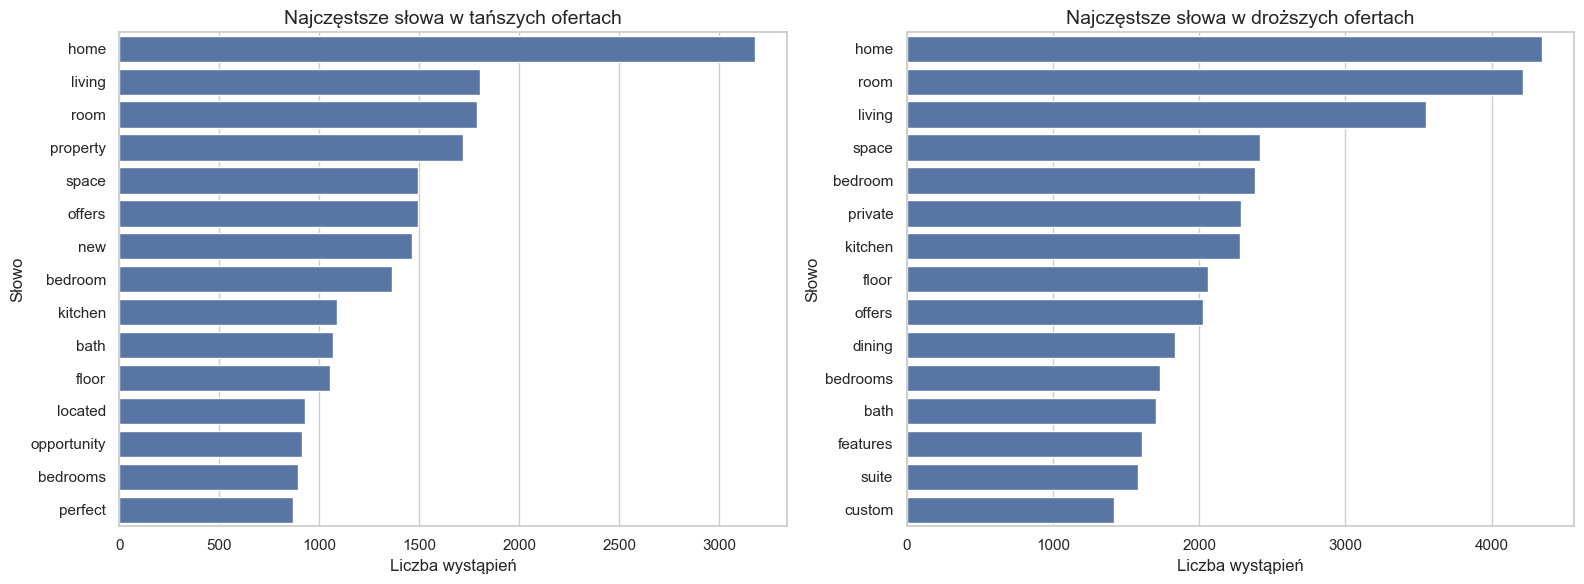

In [22]:
# ============================================================
# Najczęstsze słowa w tanich i drogich ofertach
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=low_price_top_words,
    x="count",
    y="word",
    ax=axes[0]
)

axes[0].set_title("Najczęstsze słowa w tańszych ofertach")
axes[0].set_xlabel("Liczba wystąpień")
axes[0].set_ylabel("Słowo")

sns.barplot(
    data=high_price_top_words,
    x="count",
    y="word",
    ax=axes[1]
)

axes[1].set_title("Najczęstsze słowa w droższych ofertach")
axes[1].set_xlabel("Liczba wystąpień")
axes[1].set_ylabel("Słowo")

plt.tight_layout()
plt.show()